<a href="https://colab.research.google.com/github/MatteoBaraldi/Machine-Learning-for-Bioengineering/blob/main/MOD-2/03_Classification/exercise_regularization_solved.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Logistic Regression Regularization: Comparison of L2, L1, and Firth's Logistic Regression

You will analyze a simulated clinical-biomarker dataset designed to contain three common problems in biomedical data:

1. limited sample size,
2. correlated predictors,
3. quasi-complete separation.

You will compare:

- unregularized logistic regression,
- L2-regularized logistic regression,
- L1-regularized logistic regression,
- logistic regression with elastic-net regularization,
- Firth's bias-reduced logistic regression.

The emphasis is not only predictive performance, but also coefficient stability, feature selection, and behavior under separation.

## Biological scenario

Suppose you are developing a diagnostic model for detecting a rare inflammatory cardiac condition. The available predictors include demographic variables, standard clinical measurements, blood biomarkers, and imaging-derived variables. The disease is rare, and some imaging markers are highly predictive, producing quasi-complete separation in small samples.

The outcome is binary:

$$
Y_i =
\begin{cases}
1, & \text{if disease is present},\\
0, & \text{if disease is absent}.
\end{cases}
$$

The goal is to compare how different logistic regression approaches behave under these conditions.

## 1. Import libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, brier_score_loss, accuracy_score, confusion_matrix
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score

np.random.seed(42)

## 2. Generate a synthetic dataset

The dataset has:

- 18 predictors,
- correlated biomarker groups,
- 4 truly disease-associated predictors,
- class imbalance,
- one predictor designed to create quasi-complete separation.

The data are simulated so that the true data-generating process is known. This lets you assess whether each method recovers the true signal or overreacts to artifacts.

In [2]:
def simulate_biomedical_data(n=200, random_state=42):
    # Initialize the NumPy random number generator for reproducibility
    rng = np.random.default_rng(random_state)

    # Generate latent standard normal factors to introduce multi-variable correlation blocks
    z1 = rng.normal(size=n)
    z2 = rng.normal(size=n)
    z3 = rng.normal(size=n)

    # Generate independent baseline clinical covariates (demographics and vitals)
    age = 55 + 12 * rng.normal(size=n)
    bmi = 27 + 4 * rng.normal(size=n)
    sbp = 120 + 15 * rng.normal(size=n)

    # Generate an inflammatory biomarker block sharing common variance via z1
    crp = 0.8 * z1 + 0.4 * rng.normal(size=n)
    il6 = 0.75 * z1 + 0.5 * rng.normal(size=n)
    fibrinogen = 0.65 * z1 + 0.6 * rng.normal(size=n)

    # Generate a structural cardiac imaging block sharing common variance via z2
    wall_thickness = 0.9 * z2 + 0.4 * rng.normal(size=n)
    edema_score = 0.8 * z2 + 0.5 * rng.normal(size=n)
    strain_abnormality = 0.7 * z2 + 0.6 * rng.normal(size=n)

    # Generate a metabolic profile block sharing common variance via z3
    glucose = 0.8 * z3 + 0.6 * rng.normal(size=n)
    insulin = 0.75 * z3 + 0.6 * rng.normal(size=n)
    triglycerides = 0.65 * z3 + 0.7 * rng.normal(size=n)

    # Generate pure white noise features to test feature selection algorithms
    noise = rng.normal(size=(n, 6))

    # Assemble all generated continuous features into a unified DataFrame
    X = pd.DataFrame({
        "age": age,
        "bmi": bmi,
        "systolic_bp": sbp,
        "crp": crp,
        "il6": il6,
        "fibrinogen": fibrinogen,
        "wall_thickness": wall_thickness,
        "edema_score": edema_score,
        "strain_abnormality": strain_abnormality,
        "glucose": glucose,
        "insulin": insulin,
        "triglycerides": triglycerides,
        "noise_1": noise[:, 0],
        "noise_2": noise[:, 1],
        "noise_3": noise[:, 2],
        "noise_4": noise[:, 3],
        "noise_5": noise[:, 4],
        "noise_6": noise[:, 5],
    })

    # Standardize data to zero mean and unit variance for stable parameter scaling
    Xs = (X - X.mean()) / X.std(ddof=0)

    # Define the true sparse linear predictor using a subset of continuous features
    eta = (
        -4.0
        + 0.55 * Xs["age"]
        + 0.95 * Xs["crp"]
        + 1.15 * Xs["edema_score"]
        + 0.65 * Xs["glucose"]
    )

    # Map the linear predictor to a probability scale using the standard logistic function
    p = 1 / (1 + np.exp(-eta))

    # Sample the binary outcome vector from the computed Bernoulli probabilities
    y = rng.binomial(1, p)

    # Synthesize a binary imaging flag engineered to exhibit quasi-separation relative to y
    sep = np.where(y == 1, rng.binomial(1, 0.88, n), rng.binomial(1, 0.04, n))
    X["late_gadolinium_flag"] = sep

    return X, pd.Series(y, name="disease")

# Execute the simulator function to obtain features and targets
X, y = simulate_biomedical_data()

# Store feature names for indexing downstream models
features = X.columns

# Display the head of the generated feature set
X.head()

,age,bmi,systolic_bp,crp,il6,fibrinogen,wall_thickness,edema_score,strain_abnormality,glucose,insulin,triglycerides,noise_1,noise_2,noise_3,noise_4,noise_5,noise_6,late_gadolinium_flag
0,61.184925,23.619819,119.110760,-0.285243,0.819803,0.165105,0.287935,0.044084,-0.087419,-0.411331,-0.460978,-0.298477,1.249023,0.687692,1.966127,-1.547833,-0.265360,-0.462521,0
1,48.069533,22.665205,109.060696,-1.026465,-0.941980,0.003624,1.443716,0.793047,0.879122,0.745535,0.994372,0.806768,-1.973683,1.060327,-0.270397,0.739631,2.359772,-0.353244,1
2,70.293367,28.378420,113.782904,0.768452,0.460804,1.246517,-0.040244,0.289473,0.117889,0.825127,0.562695,1.145338,-0.421153,0.118664,0.987247,-0.566713,-0.630962,1.057189,0
3,47.468950,28.517120,129.508656,0.711493,0.459596,-0.241691,0.415685,0.641078,0.813632,-0.733527,-0.172482,-0.943269,0.378639,-2.044728,-1.225392,1.501236,0.401928,-0.762196,1
4,47.360617,32.149324,120.044899,-1.821054,-1.753602,-1.455586,-1.808213,-2.342533,-0.786607,-0.102630,1.098248,-0.260110,-0.170410,0.013237,0.735733,-1.358263,-0.840949,0.272956,0


## 3. Implemention of Firth's logistic regression

Firth's logistic regression maximizes the penalized likelihood

$$
\ell_F(\beta) = \ell(\beta) + \frac{1}{2}\log |I(\beta)|,
$$

where I(beta) is the Fisher information matrix. This correction reduces first-order small-sample bias and gives finite estimates in many cases of complete or quasi-complete separation.

The implementation below uses the adjusted-score Newton algorithm.

In [3]:
class FirthLogisticRegression(BaseEstimator, ClassifierMixin):
    """Small educational implementation of Firth's logistic regression.

    This implementation is intended for teaching and moderate-size datasets.
    It supports binary outcomes and dense numeric predictors.
    """

    def __init__(self, max_iter=100, tol=1e-7, step_halving=25): #initialize optimization hyper-parameters for convergence and line search
        self.max_iter = max_iter
        self.tol = tol
        self.step_halving = step_halving

    @staticmethod
    def _sigmoid(z): #clip input values to prevent underflow/overflow errors in exponential execution
        z = np.clip(z, -35, 35)
        return 1 / (1 + np.exp(-z))

    def _penalized_loglik(self, X_design, y, beta): #calculate linear predictors and map them to conditional probabilities
        eta = X_design @ beta
        mu = self._sigmoid(eta)
        eps = 1e-12
        loglik = np.sum(y * np.log(mu + eps) + (1 - y) * np.log(1 - mu + eps)) #compute the baseline unpenalized Bernoulli log-likelihood
        w = mu * (1 - mu) #construct the diagonal weight matrix entries from the variance profile
        I = X_design.T @ (w[:, None] * X_design) #calculate the Fisher Information matrix for the current sample coordinates
        sign, logdet = np.linalg.slogdet(I + 1e-9 * np.eye(I.shape[0])) #compute the log-determinant of the Information matrix using a small ridge penalty for numerical stability
        if sign <= 0:
            return -np.inf #return Jeffreys-prior penalized log-likelihood object
        return loglik + 0.5 * logdet

    def fit(self, X, y): #enforce floating-point NumPy matrix representations for inputs
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float)
        n, p = X.shape
        X_design = np.column_stack([np.ones(n), X]) #horizontal stack to incorporate a column of ones for the intercept term
        beta = np.zeros(p + 1) #initialize the coefficient vector

        for iteration in range(self.max_iter): #execute Modified Newton-Raphson optimization loop
            eta = X_design @ beta #compute current probabilities and variance weight factors
            mu = self._sigmoid(eta)
            w = np.clip(mu * (1 - mu), 1e-9, None)

            I = X_design.T @ (w[:, None] * X_design) #reconstruct Fisher Information matrix and compute its Moore-Penrose pseudo-inverse
            I_inv = np.linalg.pinv(I)

            # Diagonal of the hat matrix H = W^(1/2) X I^-1 X' W^(1/2)
            h = np.sum((X_design @ I_inv) * X_design, axis=1) * w

            #compute the Firth-adjusted score vector incorporating the leverage weights
            adjusted_score = X_design.T @ (y - mu + h * (0.5 - mu))
            delta = I_inv @ adjusted_score

            old_obj = self._penalized_loglik(X_design, y, beta) #store the current objective value to evaluate line search candidates
            step = 1.0
            accepted = False
            for _ in range(self.step_halving): #perform step-halving back-tracking line search to guarantee monotonic optimization steps
                beta_candidate = beta + step * delta
                new_obj = self._penalized_loglik(X_design, y, beta_candidate)
                if new_obj >= old_obj:
                    beta = beta_candidate
                    accepted = True
                    break
                step *= 0.5

            if not accepted: #fallback to a small static step if the backtracking routine fails to improve the objective
                beta = beta + 0.1 * delta

            if np.max(np.abs(step * delta)) < self.tol: #terminate early if the maximum absolute parameter change falls below convergence tolerance
                break

        self.intercept_ = np.array([beta[0]]) #export fitted model attributes adhering to standard scikit-learn API conventions
        self.coef_ = beta[1:].reshape(1, -1)
        self.n_iter_ = iteration + 1
        self.classes_ = np.array([0, 1])
        return self

    def predict_proba(self, X):
        X = np.asarray(X, dtype=float) #validate array format and compute the linear activation using stored parameters
        eta = self.intercept_[0] + X @ self.coef_.ravel()
        p = self._sigmoid(eta) #map activations to positive class probabilities
        return np.column_stack([1 - p, p]) #return a 2D array containing probabilities for both negative and positive classes

    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int) #generate discrete binary classifications using a standard 0.5 probability threshold

## 4. Train-test split

* Use train_test_split to define training and testing sets (X_train, X_train, y_train, y_test)
* Use the same split for all methods below
* Define an array of feature names (features)

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.35, stratify=y, random_state=7
) # split the dataset into stratified train and test subsets
features = X.columns # keep track of feature column names
print('Percentage of cases in train: {}'.format(np.sum(y_train)/len(y_train))) # print the proportion of positive cases

Percentage of cases in train: 0.046153846153846156


## 5. Model without regularization

* Fit a logistic regression model without applying regularization. Use the following parameters for LogisticRegression:
  * C = np.inf
  * solver="saga"
  * max_iter=10000
  * tol=1e-6
    
* Assess performance by computing the AUC on the test set

* Write a function that takes as inputs:
  * Xtrain
  * y_train
  * the class of the model (LogisticRegression in this case)
  * an arbitrary number of keyword parameters, used to pass keyword parameters of the model
  
  The function should perform a 5-fold random split of the training data and compute the model coefficients for each fold
  
* Write a function that takes as inputs the name of the features and the coefficients of the model computed by the previous function and that create a bar plot of the coefficients with the following properties:
    * Features ordered by the absolute magnitude of their coefficients
    * Display the mean and standard deviation
    * Include a visual indication of the full range (minimum to maximum)



* What happens to the parameters of the model if you increase max_iter and decrease tol ? Why ?
* Do the important parameters for classification correspond to the expected ones ?

In [5]:
sc = StandardScaler() # initialize the standard scaler
sc.fit(X_train) # compute mean and std from training data for scaling
X_train = sc.transform(X_train) # scale the training features
X_test = sc.transform(X_test) # scale the test features using training params
y_train = np.asarray(y_train) # convert training labels to numpy array
y_test = np.asarray(y_test) # convert test labels to numpy array
model = LogisticRegression(C = np.inf, solver="saga", max_iter=10000) # initialize unpenalized logistic regression model
model.fit(X_train, y_train) # fit the model on scaled training data
prob = model.predict_proba(X_test)[:, 1] # predict probabilities for the positive class
pred = (prob >= 0.5).astype(int) # apply 0.5 threshold to generate binary classifications
print("AUC =", roc_auc_score(y_test, prob)) # calculate and print the roc auc metric

AUC = 0.9621212121212122


In [6]:
def estimate_parameters_range(X_train, y_train, model_class, **kwargs):
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42) # initialize 5-fold stratified cross-validation
    coefs = [] # create empty list to store coefficients from each fold
    for train_idx, val_idx in cv.split(X_train, y_train):
        X_tr = X_train[train_idx] # extract training features for the current fold
        y_tr = y_train[train_idx] # extract training labels for the current fold
        model = model_class(**kwargs) # instantiate the model with given hyperparameters
        model.fit(X_tr, y_tr) # fit the model on the fold training data
        coef = model.coef_ # extract estimated model coefficients
        coefs.append(model.coef_.ravel()) # flatten and append coefficients to the tracker list
    coefs = np.array(coefs) # convert the accumulated coefficients list into a numpy array
    return coefs # return the array containing coefficients across all folds

In [7]:
def plot_parameters_range(features, coefs):
    mean_coef = coefs.mean(axis=0) # calculate the mean coefficient value for each feature
    min_coef = coefs.min(axis=0) # extract the minimum coefficient value across folds
    max_coef = coefs.max(axis=0) # extract the maximum coefficient value across folds
    std_coef = coefs.std(axis=0) # calculate the standard deviation of coefficients
    order = np.argsort(np.abs(mean_coef))[::-1] # get sorting indices by descending mean absolute magnitude
    mean_sorted = mean_coef[order] # sort mean coefficients according to descending importance
    min_sorted = min_coef[order] # sort minimum coefficients according to feature importance
    max_sorted = max_coef[order] # sort maximum coefficients according to feature importance
    std_sorted = std_coef[order] # sort standard deviations according to feature importance
    features_sorted = np.array(features)[order] # sort feature names to match the ordered coefficients
    x = np.arange(len(features_sorted)) # generate tick positions for each sorted feature axis
    plt.figure() # initialize a new figure object for the coefficient plot
    plt.bar(x, mean_sorted) # plot mean coefficient magnitudes as vertical bars
    plt.errorbar(x, mean_sorted, yerr=std_sorted, fmt='none', capsize=5) # add standard deviation error bars
    for i in range(len(features_sorted)):
        plt.plot([i, i], [min_sorted[i], max_sorted[i]]) # plot vertical lines indicating total range min-to-max
    plt.xticks(x, features_sorted, rotation=90) # apply sorted feature names to x-axis ticks rotated 90 degrees
    plt.xlabel("Features (sorted by |coefficient|)") # set descriptive label for the horizontal axis
    plt.ylabel("Coefficient value") # set descriptive label for the vertical axis

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


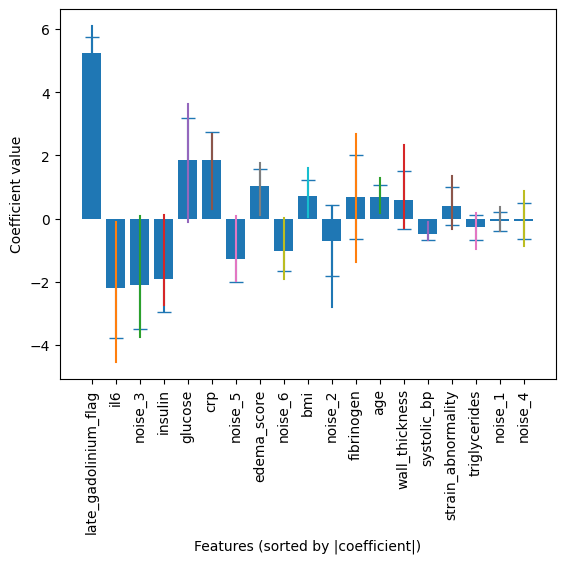

In [8]:
coefs = estimate_parameters_range(X_train, y_train, LogisticRegression, C=np.inf, solver="saga", max_iter=100000, tol=1e-8) # compute coefficients across folds using unpenalized logistic regression
plot_parameters_range(features, coefs) # generate the error bar plot for the estimated coefficient ranges

## 5. Model with L1, L2, and L1+L2 regularization

* Use 5-fold cross-validation to identify the optimal regularization paramter for L2 regularization (test the following values for C np.logspace(-4, 4, 20))
* Estimate the AUC of the best model in the testing set
* Plot the model parameters as before
* Repeat the previous points for L1 regularization, and elastic-net regularization (test the following values for l1_ratio \[0.1, 0.25, 0.5, 0.75, 0.9\])

Best C: 0.03359818286283781
Mean CV AUC: 1.0
Std CV AUC: 0.0
Test AUC: 0.9431818181818181


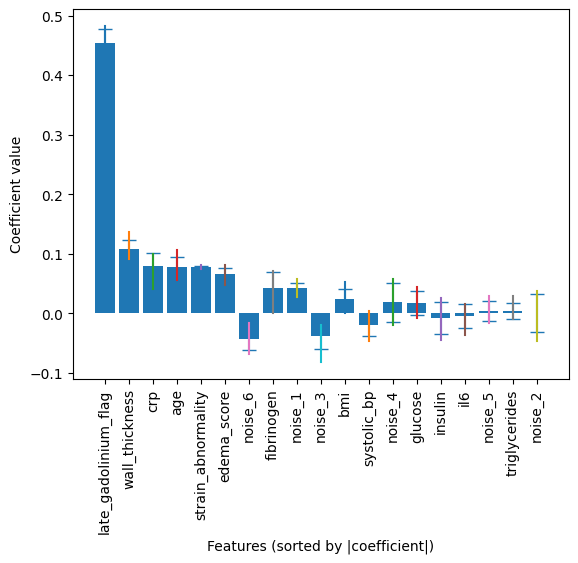

In [9]:
C_grid = np.logspace(-4, 4, 20) # define search grid of 20 logarithmic inverse regularization strengths
model_l2 = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(solver="lbfgs", max_iter=10000))
]) # initialize machine learning pipeline with scaling and ridge logistic regression
param_grid = {
    "logreg__C": C_grid
} # map the hyperparameter grid structure to the pipeline logistic regression step
grid_l2 = GridSearchCV(
    estimator=model_l2,
    param_grid=param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
    refit=True
) # configure 5-fold grid search cross-validation to optimize the roc auc metric
grid_l2.fit(X_train, y_train) # execute the cross-validation search grid over training features and labels
best_idx = grid_l2.best_index_ # extract the array index corresponding to the optimal configuration setup
mean_auc = grid_l2.cv_results_["mean_test_score"][best_idx] # retrieve validation mean roc auc for the best model setup
std_auc  = grid_l2.cv_results_["std_test_score"][best_idx] # retrieve validation standard deviation for the best model setup
print("Best C:", grid_l2.best_params_["logreg__C"]) # print out the optimized hyperparameter value found
print("Mean CV AUC:", mean_auc) # print out the average cross-validation score achieved
print("Std CV AUC:", std_auc) # print out the variation metric across validation splits
best_model = grid_l2.best_estimator_ # extract the fully optimized pipeline fitted on all training data
y_prob = best_model.predict_proba(X_test)[:, 1] # generate unseen test probability targets using the best pipeline
test_auc = roc_auc_score(y_test, y_prob) # compute generalization performance on unseen test data
print("Test AUC:", test_auc) # print out the performance evaluation metric for test records
coefs = estimate_parameters_range(X_train, y_train, LogisticRegression, C=grid_l2.best_params_["logreg__C"], solver="saga", max_iter=10000) # calculate variance bounds for optimal parameters (warning: lacks scaler pipeline)
plot_parameters_range(features, coefs) # visualize structural feature weight distributions and range deviations

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_

Best C: 0.03359818286283781
Mean CV AUC: 1.0
Std CV AUC: 0.0
Test AUC: 0.9431818181818181


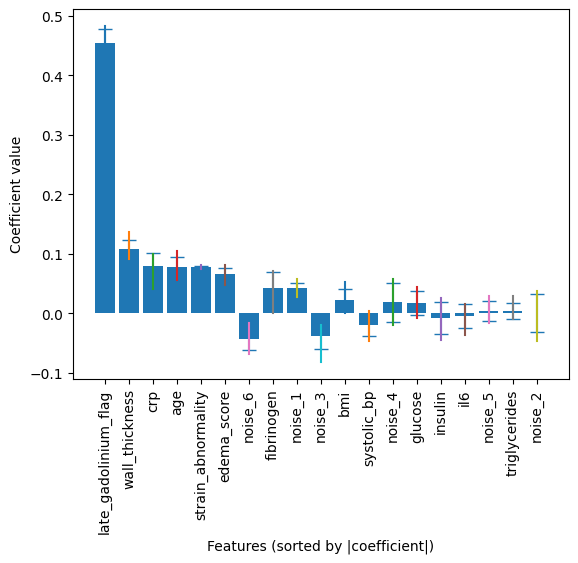

In [10]:
C_grid = np.logspace(-4, 4, 20) # define search grid of 20 logarithmic inverse regularization strengths
model_l1 = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(l1_ratio=1.0, solver="saga", max_iter=10000))
]) # initialize machine learning pipeline with scaling and lasso/elasticnet logistic regression
param_grid = {
    "logreg__C": C_grid
} # map the hyperparameter grid structure to the pipeline logistic regression step
grid_l1 = GridSearchCV(
    estimator=model_l1,
    param_grid=param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
    refit=True
) # configure 5-fold grid search cross-validation to optimize the roc auc metric
grid_l1.fit(X_train, y_train) # execute the cross-validation search grid over training features and labels
best_idx = grid_l1.best_index_ # extract the array index corresponding to the optimal configuration setup
mean_auc = grid_l1.cv_results_["mean_test_score"][best_idx] # retrieve validation mean roc auc for the best model setup
std_auc  = grid_l1.cv_results_["std_test_score"][best_idx] # retrieve validation standard deviation for the best model setup
print("Best C:", grid_l1.best_params_["logreg__C"]) # print out the optimized hyperparameter value found
print("Mean CV AUC:", mean_auc) # print out the average cross-validation score achieved
print("Std CV AUC:", std_auc) # print out the variation metric across validation splits
best_model = grid_l1.best_estimator_ # extract the fully optimized pipeline fitted on all training data
y_prob = best_model.predict_proba(X_test)[:, 1] # generate unseen test probability targets using the best pipeline
test_auc = roc_auc_score(y_test, y_prob) # compute generalization performance on unseen test data
print("Test AUC:", test_auc) # print out the performance evaluation metric for test records
coefs = estimate_parameters_range(X_train, y_train, LogisticRegression, C=grid_l1.best_params_["logreg__C"], l1_ratio=1.0, solver="saga", max_iter=10000) # calculate variance bounds for optimal parameters (warning: lacks scaler pipeline and penalty parameter)
plot_parameters_range(features, coefs) # visualize structural feature weight distributions and range deviations

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_

Best C: 0.03359818286283781
Best l1_ratio: 0.1
Mean CV AUC: 1.0
Std CV AUC: 0.0
Test AUC: 0.9431818181818181


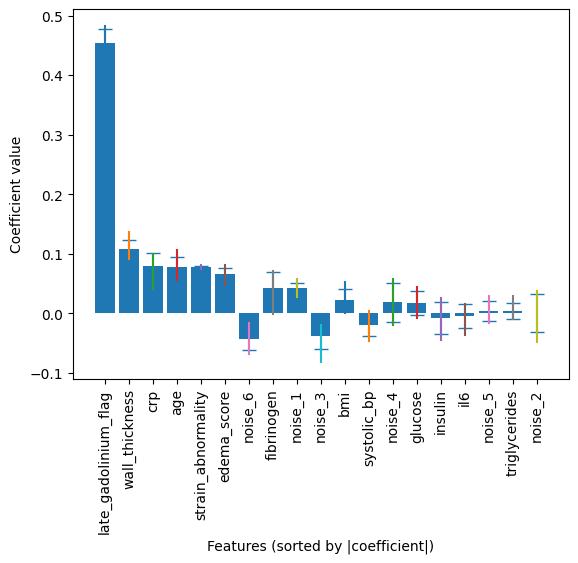

In [11]:
C_grid = np.logspace(-4, 4, 20) # define search grid of 20 logarithmic inverse regularization strengths
l1_ratio_grid = [0.1, 0.25, 0.5, 0.75, 0.9] # define the grid space for mixing parameters between l1 and l2 penalties
model_en = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(
        solver="saga",
        max_iter=10000
    ))
]) # initialize pipeline with scaling and elastic net logistic regression (requires penalty="elasticnet")
param_grid = {
    "logreg__C": C_grid,
    "logreg__l1_ratio": l1_ratio_grid
} # map both regularizer coefficients and mixing ratio paths to the logreg pipeline component
grid_en = GridSearchCV(
    estimator=model_en,
    param_grid=param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
    refit=True
) # configure 5-fold cross-validation grid search to optimize the double hyperparameter space
grid_en.fit(X_train, y_train) # execute the cross-validation search grid over training features and labels

best_idx = grid_en.best_index_ # extract the array index corresponding to the optimal configuration setup
mean_auc = grid_en.cv_results_["mean_test_score"][best_idx] # retrieve validation mean roc auc for the best model setup
std_auc  = grid_en.cv_results_["std_test_score"][best_idx] # retrieve validation standard deviation for the best model setup
print("Best C:", grid_en.best_params_["logreg__C"]) # print out the optimized hyperparameter value found
print("Best l1_ratio:", grid_en.best_params_["logreg__l1_ratio"]) # print out the optimized mixing parameter value found
print("Mean CV AUC:", mean_auc) # print out the average cross-validation score achieved
print("Std CV AUC:", std_auc) # print out the variation metric across validation splits
best_model = grid_en.best_estimator_ # extract the fully optimized pipeline fitted on all training data
y_prob = best_model.predict_proba(X_test)[:, 1] # generate unseen test probability targets using the best pipeline
test_auc = roc_auc_score(y_test, y_prob) # compute generalization performance on unseen test data
print("Test AUC:", test_auc) # print out the performance evaluation metric for test records
coefs = estimate_parameters_range(X_train, y_train, LogisticRegression, C=grid_en.best_params_["logreg__C"],
                    l1_ratio=grid_en.best_params_["logreg__l1_ratio"], solver="saga", max_iter=10000) # calculate variance bounds for optimal parameters (fixed grid object; warning: lacks scaler and penalty config)
plot_parameters_range(features, coefs) # visualize structural feature weight distributions and range deviations

## 6. Model with Firth's regularization

* Use the class above to train a Firth's logistic regression model
* Plot the model parameters as before

In [12]:
model = FirthLogisticRegression(max_iter=10000, tol=1e-8) # initialize the custom Firth logistic regression model
model.fit(X_train, y_train) # fit the Firth regression model on the training data
prob = model.predict_proba(X_test)[:, 1] # predict probabilities for the positive class on test data
pred = (prob >= 0.5).astype(int) # apply 0.5 threshold to generate binary classifications
print("AUC =", roc_auc_score(y_test, prob)) # calculate and print the test roc auc metric

AUC = 0.9734848484848485


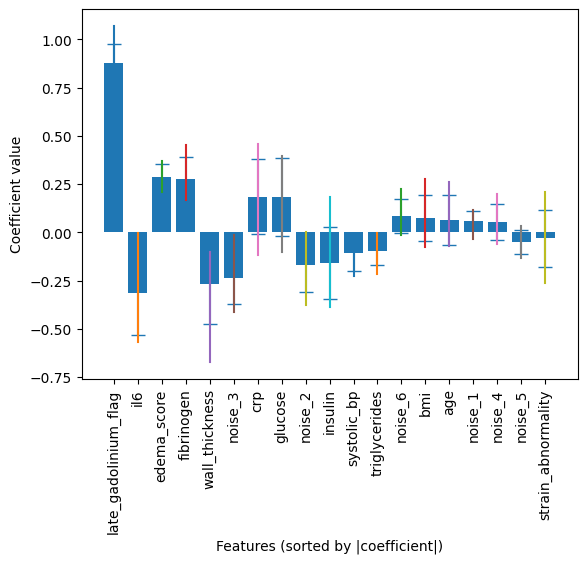

In [13]:
coefs = estimate_parameters_range(X_train, y_train, FirthLogisticRegression, max_iter=100000, tol=1e-10) # compute coefficients across folds using custom Firth logistic regression
plot_parameters_range(features, coefs) # generate the error bar plot for the estimated Firth coefficient ranges

## Expected conclusions

- The unregularized model often assigns a very large coefficient to the quasi-separating imaging flag.
- L2 regularization shrinks all coefficients and improves numerical stability, but generally keeps all predictors in the model.
- L1 regularization produces sparse models, but selected variables may be unstable under correlation.
- Firth's method reduces small-sample bias and moderates separation-driven coefficient inflation.
- The best AUC model is not necessarily the best calibrated or most interpretable model.